# Trace the Ace — Basic Exploratory Data Analysis

This notebook performs a basic exploratory analysis of the final
model-ready training dataset.

The main objectives are:

- Validate the dataset structure
- Check duplicate and missing values
- Examine the target distribution
- Summarize numerical transcript features
- Analyze categorical threshold features
- Compare features with the target
- Inspect feature correlations
- Analyze transcript text length
- Examine the number of responses per session

The master dataset is response-level, while the transcript features are
session-level. Therefore, session-level feature distributions are analyzed
using one row per unique `session_id`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


current_dir = Path.cwd().resolve()
project_root = next((path for path in [current_dir, *current_dir.parents] if (path / "Trace-The-Race-Dataset").is_dir()), None)

if project_root is None:
    raise FileNotFoundError("Trace-The-Race-Dataset folder was not found.")

dataset_root = project_root / "Trace-The-Race-Dataset"
master_file = dataset_root / "outputs" / "03_master_dataset" / "master_train.parquet"

df = pd.read_parquet(master_file)
df.columns = df.columns.str.strip().str.lower()

df["response_id"] = df["response_id"].astype("string").str.strip()
df["session_id"] = df["session_id"].astype("string").str.strip()
df["correct"] = pd.to_numeric(df["correct"], errors="coerce")

session_df = df.drop_duplicates("session_id").copy()


numerical_features = [
    "total_turns",
    "total_words",
    "session_duration_minutes",
    "turns_per_minute",
    "student_turns",
    "tutor_turns",
    "student_turn_ratio",
    "student_word_ratio",
    "avg_student_words_per_turn",
    "avg_tutor_words_per_turn",
    "student_short_turn_ratio",
    "student_long_turn_ratio",
    "student_numeric_turn_ratio",
    "student_question_ratio",
    "tutor_question_ratio",
    "student_response_after_tutor_question_ratio",
    "speaker_switch_rate",
    "longest_tutor_streak_ratio",
    "longest_student_streak_ratio",
    "background_turn_ratio",
]

band_features = [
    "session_turn_volume_band",
    "session_duration_band",
    "student_turn_share_band",
    "student_response_length_band",
    "student_short_turn_band",
    "tutor_questioning_band",
    "dialogue_switch_band",
]

numerical_features = [column for column in numerical_features if column in df.columns]
band_features = [column for column in band_features if column in df.columns]

print("Master file       :", master_file)
print("Rows              :", f"{len(df):,}")
print("Columns           :", df.shape[1])
print("Unique responses  :", f"{df['response_id'].nunique():,}")
print("Unique sessions   :", f"{df['session_id'].nunique():,}")

display(df.head())

Master file       : C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\Trace-The-Race-Dataset\outputs\03_master_dataset\master_train.parquet
Rows              : 35,072
Columns           : 36
Unique responses  : 35,072
Unique sessions   : 22,821


,response_id,session_id,learning_objective,correct,learning_objective_id,source_file,transcript_text,student_text,tutor_text,total_turns,total_words,session_duration_minutes,turns_per_minute,student_turns,tutor_turns,student_turn_ratio,student_word_ratio,avg_student_words_per_turn,avg_tutor_words_per_turn,student_short_turn_ratio,student_long_turn_ratio,student_numeric_turn_ratio,student_question_ratio,tutor_question_ratio,student_response_after_tutor_question_ratio,speaker_switch_rate,longest_tutor_streak_ratio,longest_student_streak_ratio,background_turn_ratio,session_turn_volume_band,session_duration_band,student_turn_share_band,student_response_length_band,student_short_turn_band,tutor_questioning_band,dialogue_switch_band
0,aaaavsh,bcaufvc,Knowing the value of each digit in numbers wit...,1,dqibnvd,bcaufvc.csv,"[BACKGROUND] [unclear]\n[TUTOR] Miss, I can't ...","Can you hear me? Hello?\nYeah, I hear you. Can...","Miss, I can't hear.\nCan you hear me? [unclear...",330,3405,44.7500,7.3743,150,169,0.4545,0.2822,6.4067,13.6391,0.4533,0.2133,0.3333,0.1333,0.5444,0.9022,0.8491,0.0414,0.0267,0.0333,HIGH,MEDIUM,MEDIUM,LOW,MEDIUM,LOW,HIGH
1,aaabhzi,eyutanf,Adding and subtracting tens to a 2-digit number.,1,eukmzxl,eyutanf.csv,[TUTOR] Yay! Hello!\n[STUDENT] Hello.\n[TUTOR]...,Hello.\nHello.\nI was one minute early.\nI'm o...,Yay! Hello!\nHello.\nHello. [Speaker:Backgroun...,280,5280,44.8500,6.2430,123,144,0.4393,0.3680,15.7967,22.1181,0.3740,0.4228,0.3252,0.1301,0.5556,0.7875,0.8421,0.0208,0.0244,0.0464,MEDIUM,HIGH,MEDIUM,HIGH,LOW,LOW,HIGH
2,aaahpnz,juptkxd,Comparing and ordering fractions by finding a ...,0,fjbqcsv,juptkxd.csv,[BACKGROUND] [unclear]\n[TUTOR] Is it me you a...,Hello.\nHello.\nYes.\nGood. How are you?\nNorm...,"Is it me you are looking for?\nOkay, so did yo...",291,4638,44.9500,6.4739,139,139,0.4777,0.3952,13.1871,18.3669,0.4245,0.3597,0.5108,0.1223,0.5612,0.8846,0.8520,0.0216,0.0360,0.0447,MEDIUM,HIGH,HIGH,HIGH,LOW,LOW,HIGH
3,aaajpom,ntwkcfj,Comparing fractions using reasoning.,0,acvbcev,ntwkcfj.csv,[BACKGROUND] [unclear]\n[TUTOR] Hello?\n[STUDE...,"Hello, Tobias. Can you hear me?\nOkay, that's ...","Hello?\nYes, I can hear you.\nGood. Why are yo...",265,4792,45.0667,5.8802,124,132,0.4679,0.2619,10.1210,25.9167,0.4194,0.2984,0.3790,0.1694,0.7273,0.8646,0.8196,0.0227,0.0323,0.0340,MEDIUM,HIGH,HIGH,HIGH,LOW,HIGH,MEDIUM
4,aaamwux,jqriibm,Counting in multiples.,0,krfuudx,jqriibm.csv,[BACKGROUND] [unclear]\n[TUTOR] Hello.\n[STUDE...,"Hello.\nGood. Okay, how was this week for you?...",Hello.\nHello.\nAre you feeling tired today?\n...,270,2640,35.0333,7.7069,102,153,0.3778,0.2197,5.6863,13.0131,0.5196,0.1667,0.3725,0.1176,0.6797,0.7404,0.7480,0.0392,0.0196,0.0556,MEDIUM,LOW,LOW,LOW,MEDIUM,MEDIUM,LOW


## 1. Dataset Overview

The master table contains one row for every assessment response.

- `response_id` identifies an assessment response
- `session_id` identifies the tutoring session
- One session may contain multiple assessment responses
- `correct` is the binary prediction target

In [2]:
overview = pd.DataFrame({
    "Metric": [
        "Total rows",
        "Total columns",
        "Unique response IDs",
        "Unique session IDs",
        "Repeated session rows",
        "Duplicate response IDs",
        "Fully duplicated rows",
    ],
    "Value": [
        len(df),
        df.shape[1],
        df["response_id"].nunique(),
        df["session_id"].nunique(),
        df["session_id"].duplicated().sum(),
        df["response_id"].duplicated().sum(),
        df.duplicated().sum(),
    ],
})

display(overview)


missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": df.isna().mean() * 100,
}).sort_values("missing_percentage", ascending=False)

display(missing_summary.head(15))


missing_plot = missing_summary[missing_summary["missing_count"] > 0].head(15)

if len(missing_plot) > 0:
    plt.figure(figsize=(10, 5))
    sns.barplot(x=missing_plot["missing_percentage"], y=missing_plot.index)
    plt.title("Top Missing-Value Columns")
    plt.xlabel("Missing Percentage")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values found.")

,Metric,Value
0,Total rows,35072
1,Total columns,36
2,Unique response IDs,35072
3,Unique session IDs,22821
4,Repeated session rows,12251
5,Duplicate response IDs,0
6,Fully duplicated rows,0


,missing_count,missing_percentage
response_id,0,0.0000
session_id,0,0.0000
learning_objective,0,0.0000
correct,0,0.0000
learning_objective_id,0,0.0000
source_file,0,0.0000
transcript_text,0,0.0000
student_text,0,0.0000
tutor_text,0,0.0000
total_turns,0,0.0000


No missing values found.


 > No messing values ✅

## 2. Target Distribution

The `correct` column contains:

- `0` — Incorrect response
- `1` — Correct response

The following plots show the class balance of the training dataset.

,label,meaning,count,percentage
0,0,Incorrect,10435,29.7500
1,1,Correct,24637,70.2500


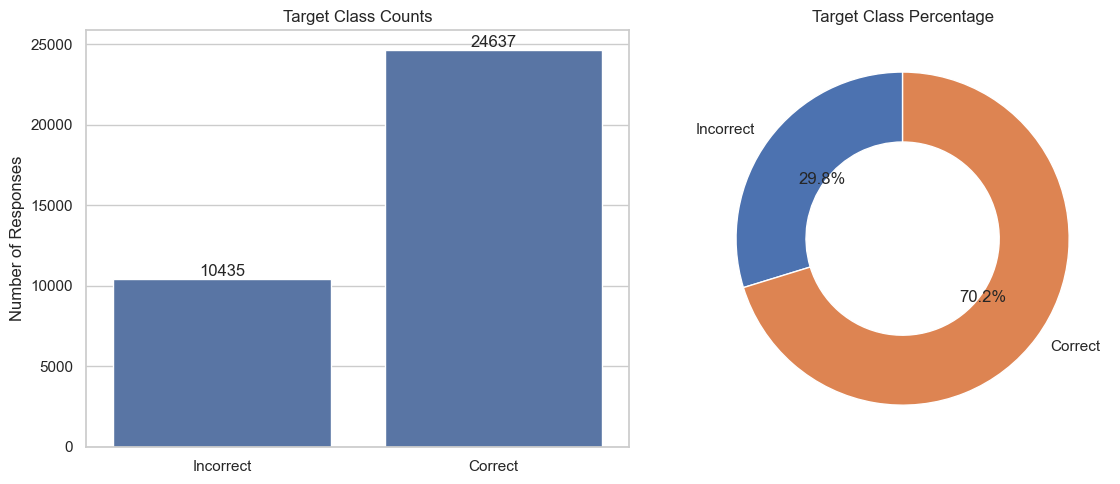

In [3]:
target_counts = df["correct"].value_counts().sort_index()
target_percentage = df["correct"].value_counts(normalize=True).sort_index() * 100

target_summary = pd.DataFrame({
    "label": target_counts.index,
    "meaning": ["Incorrect", "Correct"],
    "count": target_counts.values,
    "percentage": target_percentage.values,
})

display(target_summary.round(2))


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.barplot(data=target_summary, x="meaning", y="count", ax=axes[0])

for container in axes[0].containers:
    axes[0].bar_label(container, fmt="%d")

axes[0].set_title("Target Class Counts")
axes[0].set_xlabel("")
axes[0].set_ylabel("Number of Responses")


axes[1].pie(
    target_counts.values,
    labels=["Incorrect", "Correct"],
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.42},
)

axes[1].set_title("Target Class Percentage")

plt.tight_layout()
plt.show()

## 3. Numerical Feature Summary

The twenty transcript features describe:

- Session size and duration
- Student and tutor participation
- Student response style
- Tutor questioning behavior
- Conversation dynamics
- Transcript quality

One row per unique session is used for distribution analysis.

In [4]:
session_numeric = session_df[numerical_features].apply(pd.to_numeric, errors="coerce")
session_numeric = session_numeric.replace([np.inf, -np.inf], np.nan)

numerical_summary = session_numeric.describe().T

numerical_summary["missing_percentage"] = session_numeric.isna().mean() * 100
numerical_summary["zero_percentage"] = session_numeric.eq(0).mean() * 100
numerical_summary["unique_values"] = session_numeric.nunique()
numerical_summary["skewness"] = session_numeric.skew()

numerical_summary = numerical_summary[
    [
        "count",
        "mean",
        "std",
        "min",
        "25%",
        "50%",
        "75%",
        "max",
        "zero_percentage",
        "unique_values",
        "skewness",
    ]
]

display(numerical_summary.round(3))

,count,mean,std,min,25%,50%,75%,max,zero_percentage,unique_values,skewness
total_turns,"22,821.0000",269.0440,73.5100,15.0000,222.0000,267.0000,316.0000,622.0000,0.0000,501,0.0870
total_words,"22,821.0000","3,644.9220",951.1720,39.0000,"3,045.0000","3,681.0000","4,270.0000","8,663.0000",0.0000,4462,-0.1960
session_duration_minutes,"22,821.0000",41.4250,5.5450,3.4170,39.1830,43.3830,45.0830,62.0170,0.0000,1817,-1.9590
turns_per_minute,"22,821.0000",6.4920,1.5390,0.5750,5.4950,6.4460,7.4530,13.4280,0.0000,20406,0.1310
student_turns,"22,821.0000",118.1870,37.9280,0.0000,94.0000,118.0000,142.0000,295.0000,0.0220,262,0.0940
tutor_turns,"22,821.0000",140.0460,36.1430,4.0000,117.0000,139.0000,163.0000,559.0000,0.0000,275,0.1190
student_turn_ratio,"22,821.0000",0.4350,0.0590,0.0000,0.4100,0.4460,0.4730,0.8100,0.0220,7973,-1.5150
student_word_ratio,"22,821.0000",0.2680,0.0940,0.0000,0.2030,0.2630,0.3270,0.8680,0.0220,22539,0.4620
avg_student_words_per_turn,"22,821.0000",8.3660,3.0130,0.0000,6.2930,7.8820,9.9000,38.6470,0.0220,18534,1.2450
avg_tutor_words_per_turn,"22,821.0000",18.7150,5.3490,1.2000,15.0860,17.9560,21.5140,65.5610,0.0000,20566,1.0640


## 4. Numerical Feature Distributions

Histograms and density curves are used to examine:

- Feature shape
- Skewness
- Extreme values
- Zero-heavy distributions
- Differences between count and ratio features

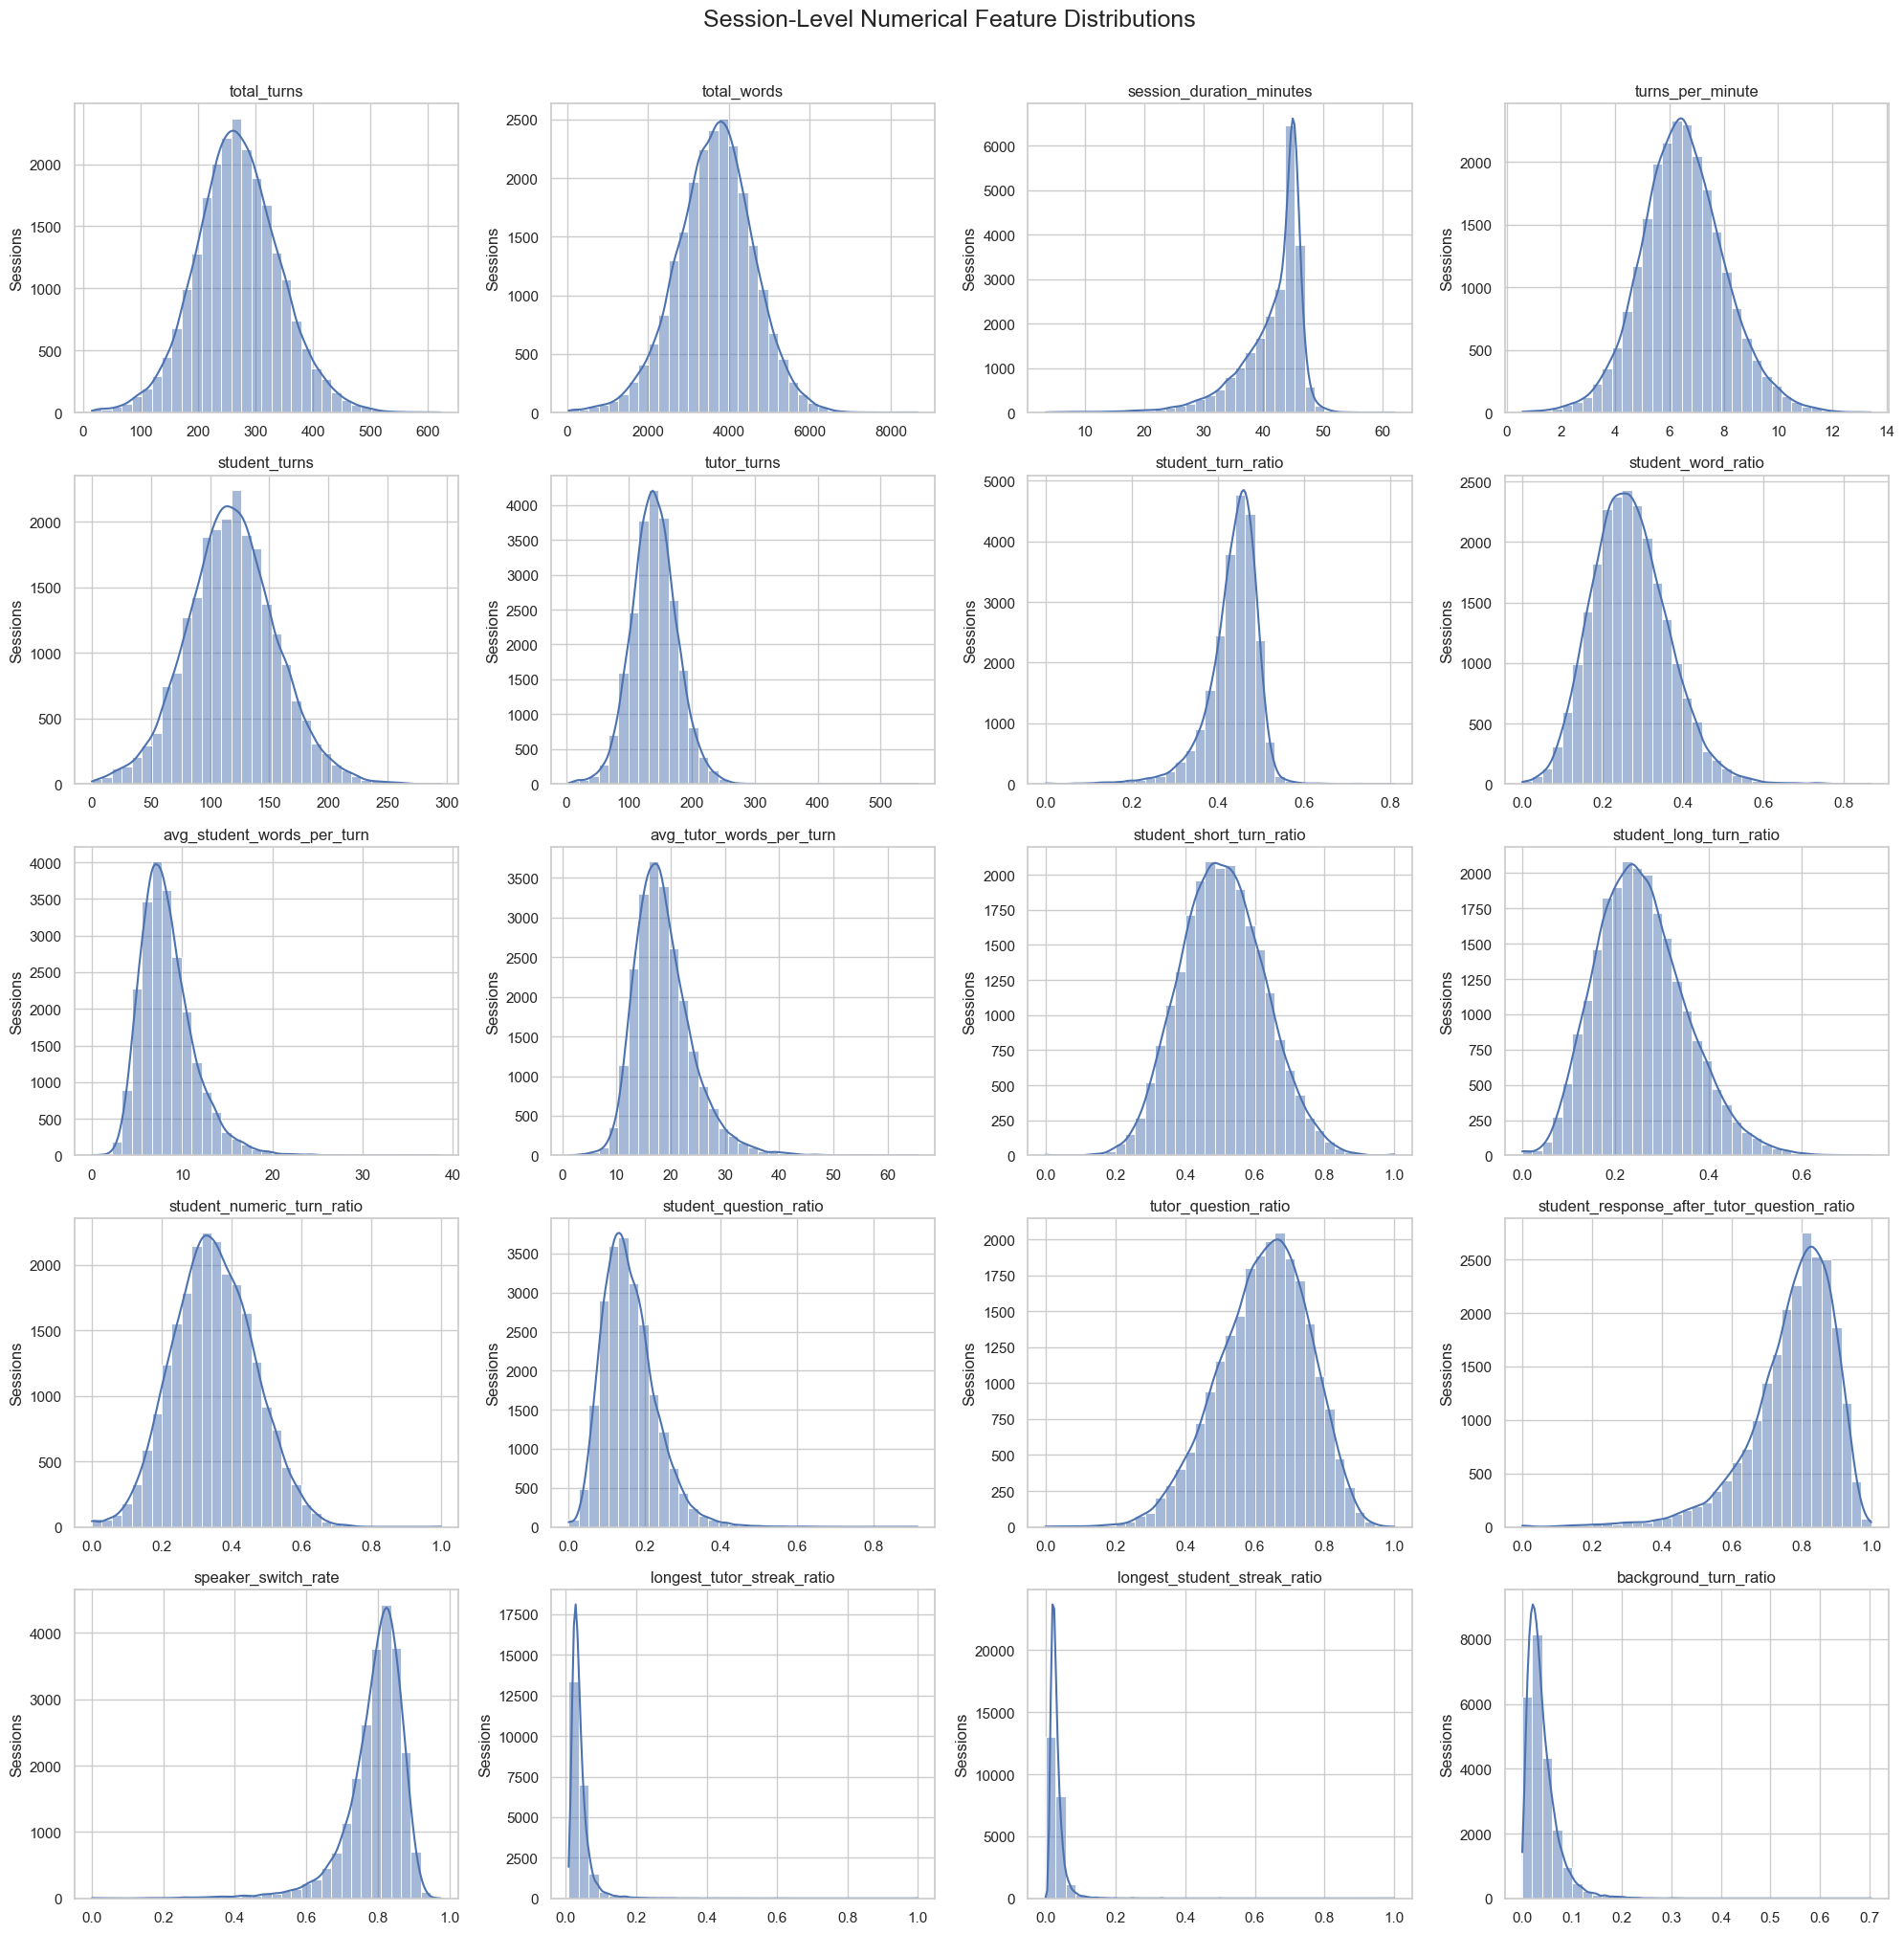

In [5]:
rows = int(np.ceil(len(numerical_features) / 4))

fig, axes = plt.subplots(rows, 4, figsize=(20, rows * 4))
axes = axes.flatten()

for index, feature in enumerate(numerical_features):
    values = session_numeric[feature].dropna()

    sns.histplot(values, bins=35, kde=True, ax=axes[index])
    axes[index].set_title(feature)
    axes[index].set_xlabel("")
    axes[index].set_ylabel("Sessions")

for index in range(len(numerical_features), len(axes)):
    axes[index].axis("off")

plt.suptitle("Session-Level Numerical Feature Distributions", fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

### Session-Level Numerical Feature Summary

* Most sessions contain around **250–320 total turns**, with a roughly bell-shaped distribution.
* The total number of words is mainly concentrated around **3,500–4,500 words per session**.
* Session duration is strongly concentrated near **40–46 minutes**, indicating relatively consistent session lengths.
* Most sessions have approximately **5–8 turns per minute**, with a peak near 6 turns per minute.
* Student turns are generally centred around **100–140**, while tutor turns are slightly more concentrated around **110–150**.
* Students contribute roughly **40–50% of all turns**, but only about **20–35% of the total words**.
* Students usually produce around **7–10 words per turn**, whereas tutors produce approximately **15–22 words per turn**.
* The student short-turn ratio is centred near **0.50**, while the long-turn ratio is mostly around **0.20–0.30**.
* Student questions are relatively uncommon, while tutors ask questions in approximately **55–80% of their turns**.
* Students respond after tutor questions in most cases, with the response ratio mainly between **0.70 and 0.90**.
* The high speaker-switch rate, centred near **0.80**, suggests frequent back-and-forth interaction between students and tutors.
* Long uninterrupted speaker streaks and background turns are generally rare, although their distributions contain a few right-skewed outliers.


| Feature Group                      | Example Features                                                                                          | Recommended Transformation             | Reason                                                                                     |
| ---------------------------------- | --------------------------------------------------------------------------------------------------------- | -------------------------------------- | ------------------------------------------------------------------------------------------ |
| Approximately normal features      | `total_turns`, `total_words`, `turns_per_minute`, `student_turns`, `tutor_turns`                          | `StandardScaler`                       | Distributions are close to normal but have different numerical ranges.                     |
| Positively skewed count features   | `avg_student_words_per_turn`, `avg_tutor_words_per_turn`                                                  | `log1p` → `StandardScaler`             | Reduces the influence of unusually large values and right-tail outliers.                   |
| Balanced ratio features            | `student_turn_ratio`, `student_short_turn_ratio`, `student_long_turn_ratio`, `student_numeric_turn_ratio` | Keep unchanged or use `StandardScaler` | These features are bounded and reasonably distributed without severe skewness.             |
| Highly right-skewed ratio features | `longest_tutor_streak_ratio`, `longest_student_streak_ratio`, `background_turn_ratio`                     | `Yeo-Johnson` → `RobustScaler`         | Handles zero values and reduces strong right skewness.                                     |
| Ratios concentrated near 0 or 1    | `student_question_ratio`, `speaker_switch_rate`, `student_response_after_tutor_question_ratio`            | Clipped `Logit Transformation`         | Spreads values concentrated near the boundaries and improves separation for linear models. |


## 5. Skewness and Outlier Analysis

Highly skewed features may benefit from transformations such as `log1p`
during feature engineering.

The IQR method is used only to identify possible extreme values.
Rows are not removed during EDA.

,feature,skewness,lower_limit,upper_limit,outlier_count,outlier_percentage
17,longest_tutor_streak_ratio,9.7130,-0.0080,0.0780,1437,6.2970
18,longest_student_streak_ratio,10.0260,-0.0040,0.0600,1383,6.0600
2,session_duration_minutes,-1.9590,30.3330,53.9330,1113,4.8770
16,speaker_switch_rate,-2.3990,0.6320,0.9710,1036,4.5400
19,background_turn_ratio,2.6770,-0.0300,0.1000,1022,4.4780
6,student_turn_ratio,-1.5150,0.3160,0.5670,964,4.2240
15,student_response_after_tutor_question_ratio,-1.5330,0.4950,1.0790,778,3.4090
9,avg_tutor_words_per_turn,1.0640,5.4430,31.1570,655,2.8700
8,avg_student_words_per_turn,1.2450,0.8830,15.3100,655,2.8700
13,student_question_ratio,1.0550,-0.0220,0.3310,472,2.0680


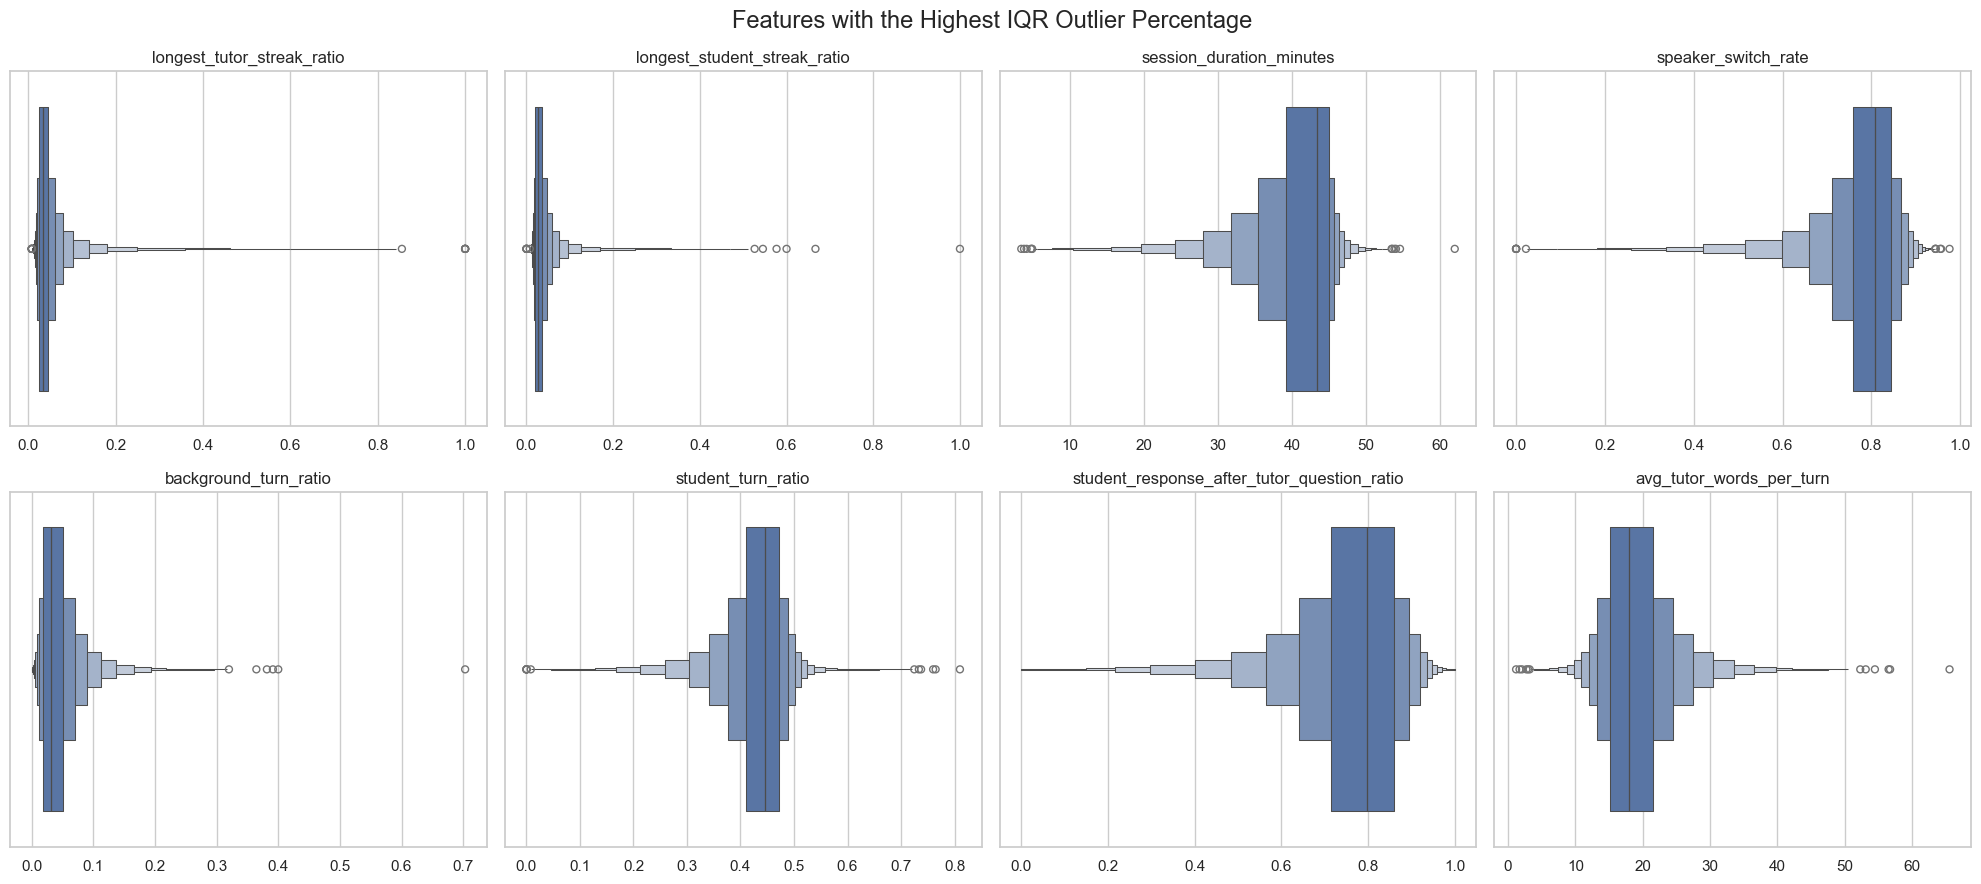

In [10]:
outlier_rows = []

for feature in numerical_features:
    values = session_numeric[feature].dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    outlier_count = ((values < lower_limit) | (values > upper_limit)).sum()

    outlier_rows.append({
        "feature": feature,
        "skewness": values.skew(),
        "lower_limit": lower_limit,
        "upper_limit": upper_limit,
        "outlier_count": outlier_count,
        "outlier_percentage": outlier_count / len(values) * 100,
    })

outlier_summary = pd.DataFrame(outlier_rows)
outlier_summary = outlier_summary.sort_values("outlier_percentage", ascending=False)

display(outlier_summary.round(3))


top_outlier_features = outlier_summary.head(8)["feature"].tolist()

fig, axes = plt.subplots(2, 4, figsize=(20, 9))
axes = axes.flatten()

for index, feature in enumerate(top_outlier_features):
    sns.boxenplot(x=session_numeric[feature], ax=axes[index])
    axes[index].set_title(feature)
    axes[index].set_xlabel("")

plt.suptitle("Features with the Highest IQR Outlier Percentage", fontsize=17)
plt.tight_layout()
plt.show()

### IQR Outlier Analysis Summary

* The boxen plots highlight the eight features with the highest IQR-based outlier percentages.
* `longest_tutor_streak_ratio` is strongly right-skewed, with most values close to zero and several extreme observations.
* `longest_student_streak_ratio` shows a similar pattern, including a few values approaching 1.0.
* `background_turn_ratio` is highly right-skewed, although most sessions contain very little background activity.
* `session_duration_minutes` is concentrated around **35–47 minutes**, with unusually short and long sessions on both sides.
* `speaker_switch_rate` is mainly concentrated around **0.70–0.90**, with most outliers appearing in the lower range.
* `student_turn_ratio` is relatively balanced around **0.40–0.50**, but contains a small number of extreme observations.
* `student_response_after_tutor_question_ratio` is concentrated near **0.70–0.90**, with a long lower tail.
* `avg_tutor_words_per_turn` is centred around **15–25 words**, with several large upper-tail outliers.
* Overall, the ratio and streak features show stronger skewness than the general session-level numerical features.

### Recommended Outlier Treatment

| Feature or Feature Group                    | Observed Pattern                              | Recommended Treatment                                      |
| ------------------------------------------- | --------------------------------------------- | ---------------------------------------------------------- |
| `longest_tutor_streak_ratio`                | Strong right skew with extreme values         | Apply `Yeo-Johnson`, followed by `RobustScaler`            |
| `longest_student_streak_ratio`              | Strong right skew and isolated extreme ratios | Apply `Yeo-Johnson` or `log1p`, followed by `RobustScaler` |
| `background_turn_ratio`                     | Mostly near zero with a long right tail       | Use `log1p` or `Yeo-Johnson` transformation                |
| `session_duration_minutes`                  | Outliers on both lower and upper sides        | Winsorize at the 1st and 99th percentiles                  |
| `speaker_switch_rate` and response ratio    | Values concentrated close to 1                | Clip boundaries and apply a `Logit Transformation`         |
| `student_turn_ratio` and tutor word average | Moderate outliers with useful information     | Keep values or apply `RobustScaler`; avoid direct removal  |


## 6. Session Features and Correctness

Transcript features belong to sessions, while labels belong to responses.

For a cleaner session-level comparison, the mean correctness rate of each
session is calculated.

A session correctness rate of:

- `0.00` means every response was incorrect
- `1.00` means every response was correct
- A value between `0` and `1` means the session had mixed outcomes

,correlation_with_session_correct_rate
student_short_turn_ratio,-0.0569
student_question_ratio,-0.0297
tutor_turns,-0.0250
tutor_question_ratio,-0.0239
turns_per_minute,-0.0194
total_turns,-0.0153
student_numeric_turn_ratio,-0.0149
longest_tutor_streak_ratio,-0.0045
student_turns,-0.0045
longest_student_streak_ratio,-0.0015


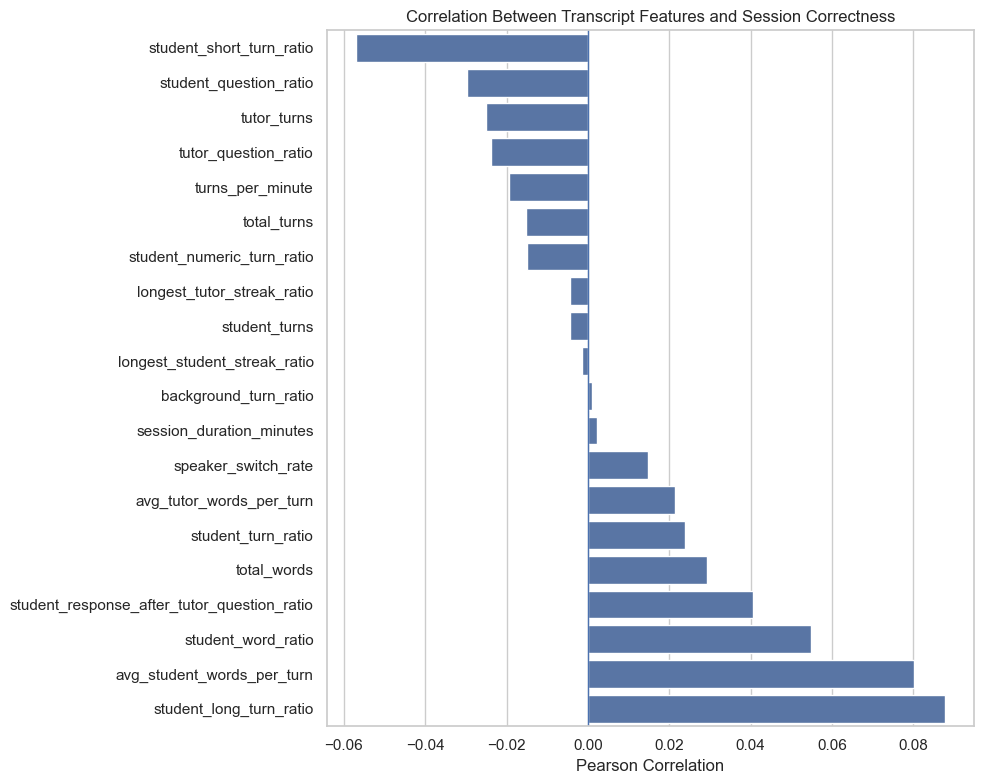

In [11]:
session_target = (
    df.groupby("session_id")
    .agg(
        session_correct_rate=("correct", "mean"),
        response_count=("correct", "size"),
    )
    .reset_index()
)

session_analysis = session_df[["session_id"] + numerical_features].merge(session_target, on="session_id", how="left")

feature_target_correlation = (
    session_analysis[numerical_features + ["session_correct_rate"]]
    .corr()["session_correct_rate"]
    .drop("session_correct_rate")
    .sort_values()
)

display(feature_target_correlation.rename("correlation_with_session_correct_rate").to_frame())


plt.figure(figsize=(10, 8))

sns.barplot(
    x=feature_target_correlation.values,
    y=feature_target_correlation.index,
)

plt.axvline(0, linewidth=1)
plt.title("Correlation Between Transcript Features and Session Correctness")
plt.xlabel("Pearson Correlation")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 7. Strongest Feature Relationships

The features with the strongest positive or negative relationships with
session correctness are visualized using regression plots.

These relationships are exploratory and do not prove that one feature
causes better learning outcomes.

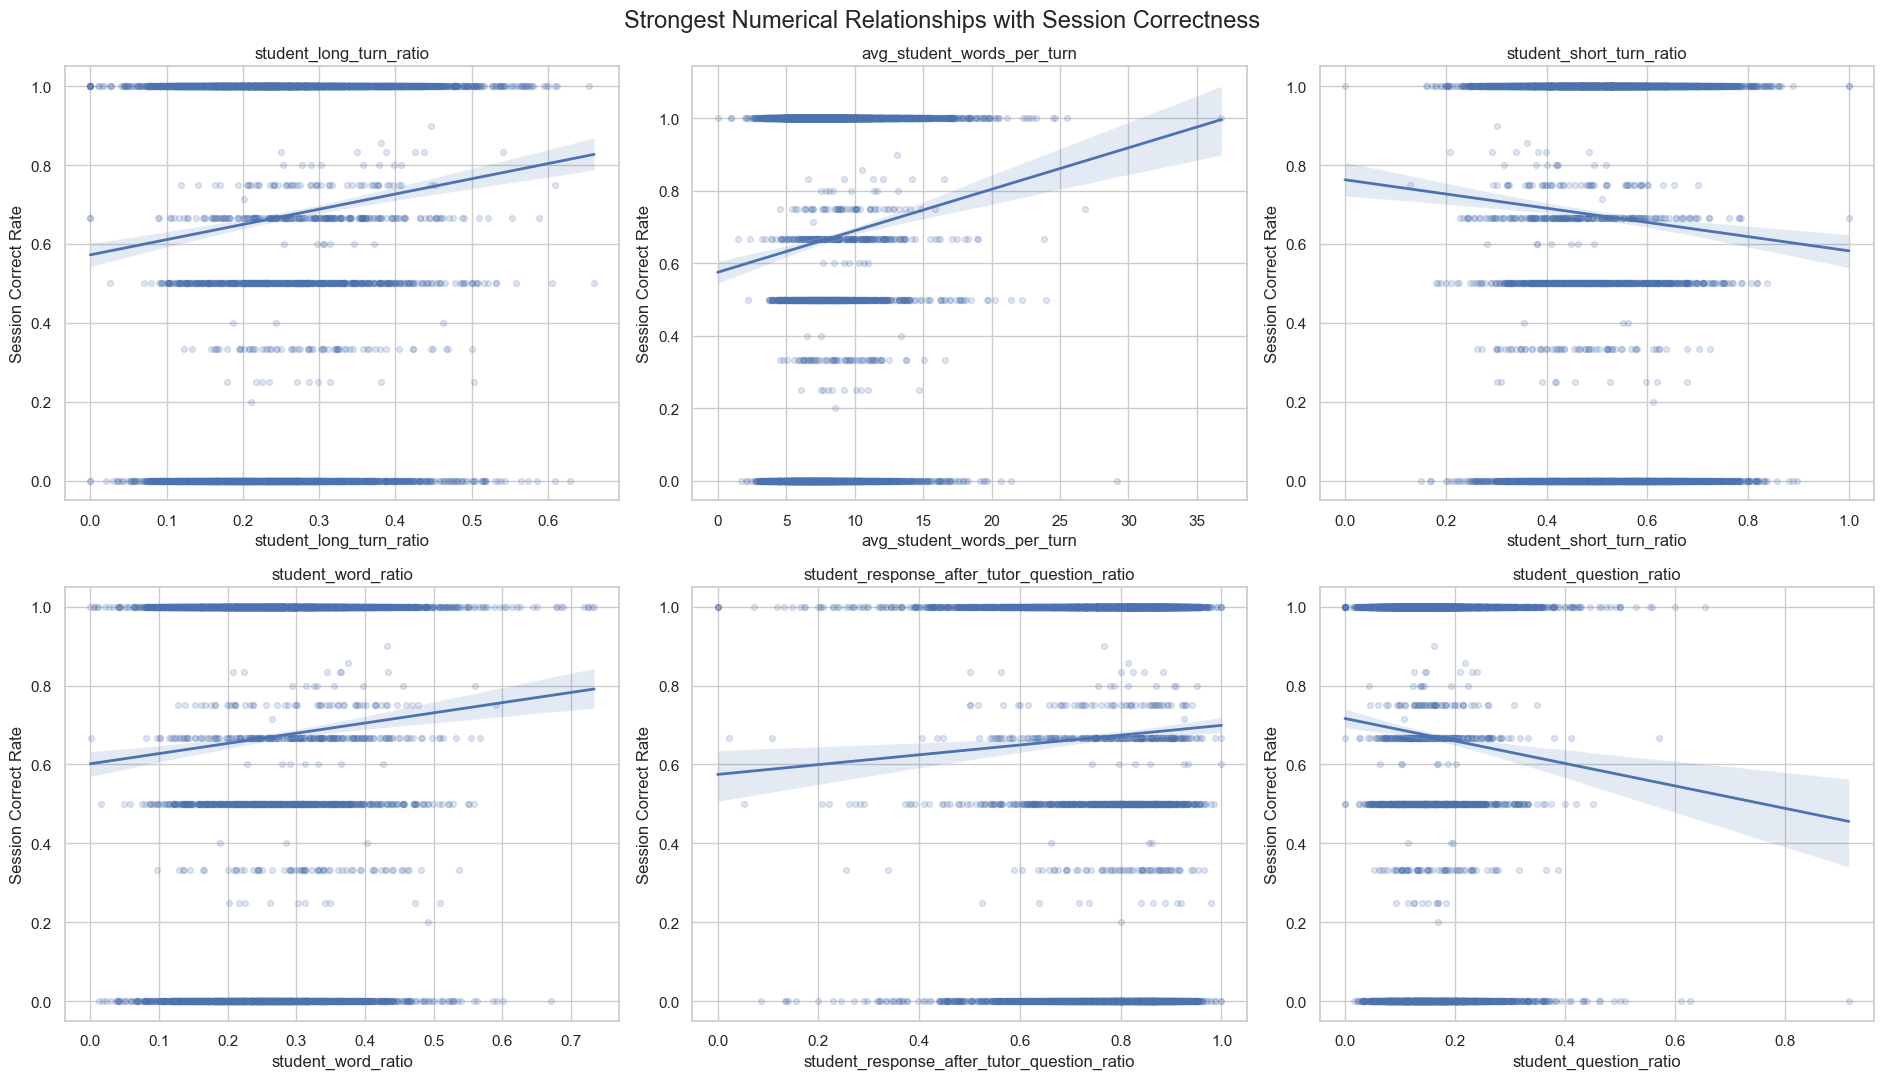

In [12]:
top_relationship_features = feature_target_correlation.abs().sort_values(ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(19, 11))
axes = axes.flatten()

plot_sample = session_analysis.sample(min(7000, len(session_analysis)), random_state=42)

for index, feature in enumerate(top_relationship_features):
    sns.regplot(
        data=plot_sample,
        x=feature,
        y="session_correct_rate",
        scatter_kws={"alpha": 0.18, "s": 18},
        line_kws={"linewidth": 2},
        ax=axes[index],
    )

    axes[index].set_title(feature)
    axes[index].set_ylabel("Session Correct Rate")

plt.suptitle("Strongest Numerical Relationships with Session Correctness", fontsize=17)
plt.tight_layout()
plt.show()

### Interpretation of the Relationship Plots

1. **`student_long_turn_ratio` shows a positive relationship with session correctness.** Sessions with more detailed student responses tend to have higher correct rates.
2. **`avg_student_words_per_turn` shows the strongest positive trend.** Students who use more words per turn generally achieve better session performance.
3. **`student_short_turn_ratio` is negatively related to correctness.** A high proportion of short responses may indicate limited engagement or understanding.
4. **`student_word_ratio` has a positive association with session correctness.** Greater student contribution to the conversation is linked with better performance.
5. **`student_response_after_tutor_question_ratio` shows a mild positive relationship.** Students who regularly respond to tutor questions tend to perform slightly better.
6. **`student_question_ratio` shows a negative trend with correctness.** This may indicate that struggling or confused students ask more questions.
7. The blue regression line shows the overall direction of the relationship between each feature and session correctness.
8. The shaded area represents the confidence interval; wider areas indicate greater uncertainty in the estimated relationship.
9. The horizontal bands at values such as `0`, `0.33`, `0.50`, `0.67`, and `1.00` occur because session correctness is calculated from a limited number of responses.
10. These plots show **association, not causation**. Therefore, they do not prove that increasing a feature will directly improve correctness.

### Overall Findings

| Relationship type | Features                                        | Interpretation                                                                               |
| ----------------- | ----------------------------------------------- | -------------------------------------------------------------------------------------------- |
| Strong positive   | `avg_student_words_per_turn`                    | More detailed student responses are associated with better correctness.                      |
| Positive          | `student_long_turn_ratio`, `student_word_ratio` | Longer responses and greater student participation relate to stronger performance.           |
| Mild positive     | `student_response_after_tutor_question_ratio`   | Responding consistently to tutor questions may support better outcomes.                      |
| Negative          | `student_short_turn_ratio`                      | Frequent short answers are associated with lower correctness.                                |
| Negative          | `student_question_ratio`                        | Students with lower performance may ask more questions because they need additional support. |
| Main caution      | All plotted features                            | The relationships are correlational and should not be interpreted as causal effects.         |


## 8. Numerical Feature Correlation

The correlation heatmap shows how strongly numerical transcript features
are related to each other.

Very high correlation may indicate that two features contain similar
information. Features are not removed here; final decisions will be based
on validation performance.

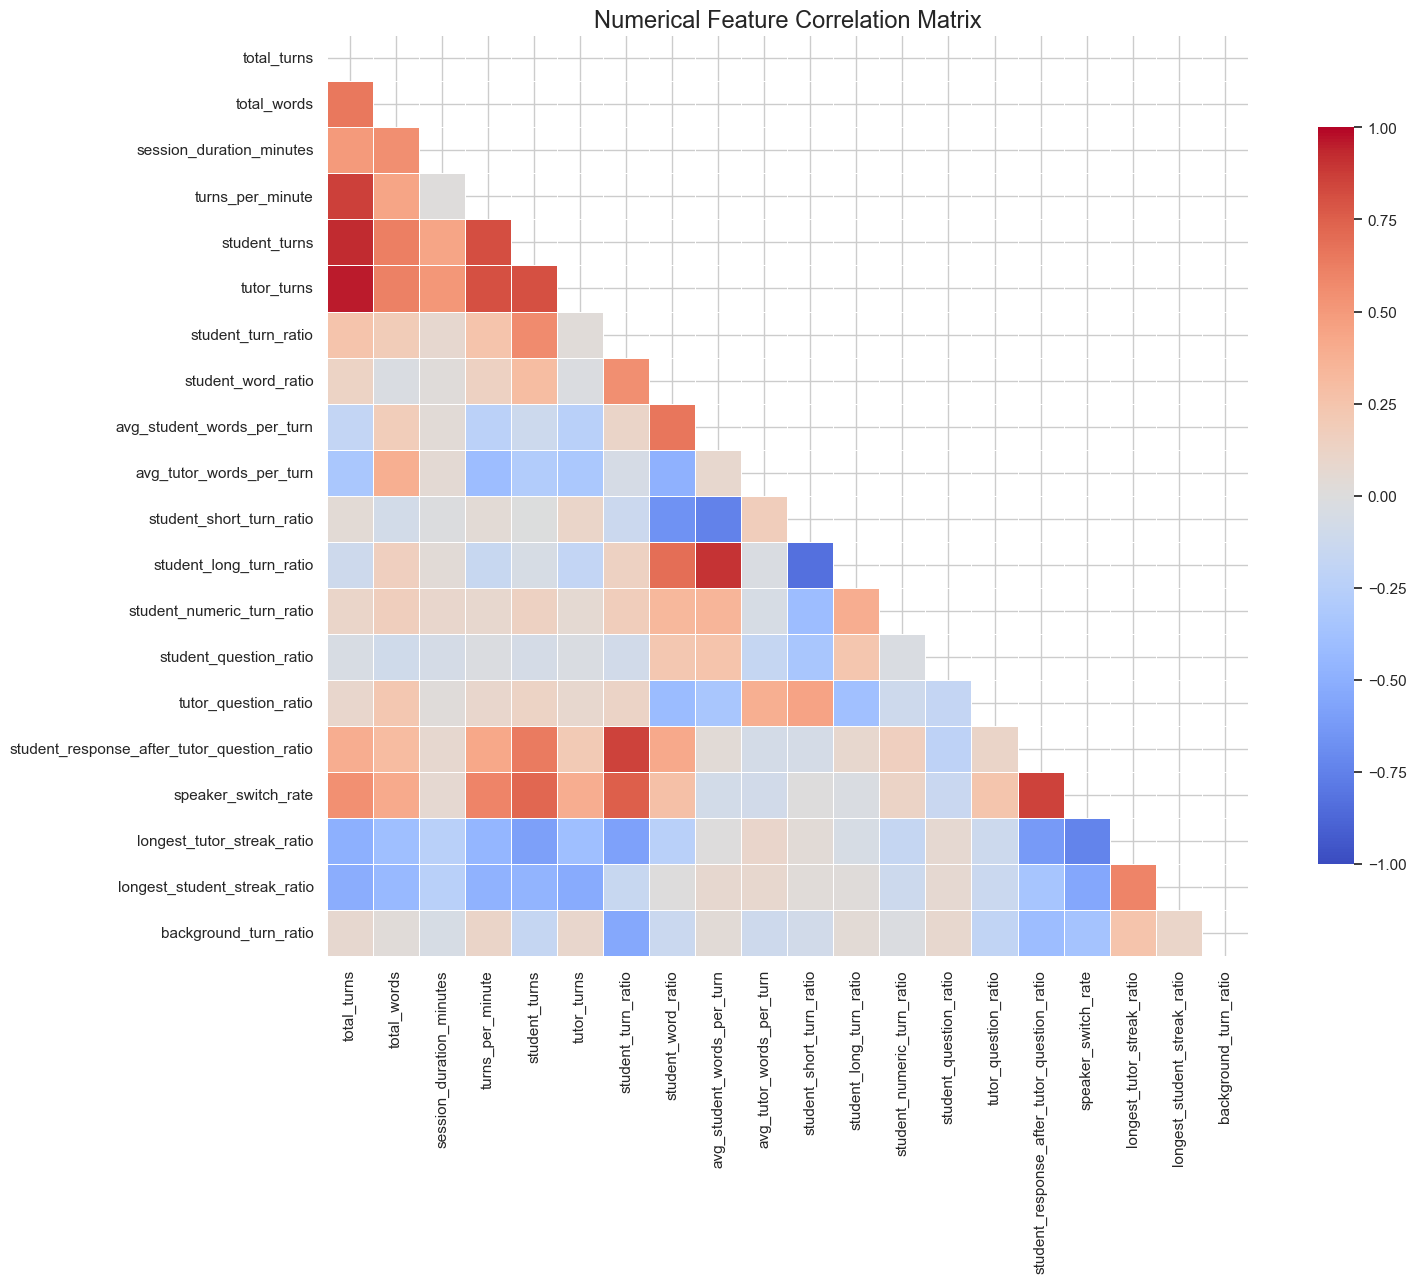

,feature_1,feature_2,correlation,absolute_correlation
4,total_turns,tutor_turns,0.9580,0.9580
3,total_turns,student_turns,0.9290,0.9290
126,avg_student_words_per_turn,student_long_turn_ratio,0.9020,0.9020
2,total_turns,turns_per_minute,0.8640,0.8640
180,student_response_after_tutor_question_ratio,speaker_switch_rate,0.8580,0.8580
107,student_turn_ratio,student_response_after_tutor_question_ratio,0.8550,0.8550


In [13]:
correlation_matrix = session_numeric.corr()

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

plt.figure(figsize=(17, 13))

sns.heatmap(
    correlation_matrix,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.4,
    cbar_kws={"shrink": 0.8},
)

plt.title("Numerical Feature Correlation Matrix", fontsize=17)
plt.tight_layout()
plt.show()


upper_triangle = correlation_matrix.where(np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool))

high_correlation_pairs = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "correlation"})
)

high_correlation_pairs["absolute_correlation"] = high_correlation_pairs["correlation"].abs()

high_correlation_pairs = (
    high_correlation_pairs[high_correlation_pairs["absolute_correlation"] >= 0.85]
    .sort_values("absolute_correlation", ascending=False)
)

display(high_correlation_pairs.round(3))

### Interpretation of the Numerical Feature Correlation Matrix

1. **`total_turns` is strongly positively correlated with both `student_turns` and `tutor_turns`**, which is expected because these two features form the total number of turns.
2. **`total_turns` and `turns_per_minute` also show a strong positive relationship**, indicating that highly active sessions contain more conversational exchanges.
3. **`student_turns` and `tutor_turns` are strongly correlated**, suggesting that students and tutors generally contribute more turns together.
4. **`avg_student_words_per_turn` has a strong positive correlation with `student_long_turn_ratio`** because longer student responses naturally contain more words.
5. **`avg_student_words_per_turn` and `student_short_turn_ratio` show a strong negative correlation**, meaning sessions with longer answers contain fewer short student turns.
6. **`student_short_turn_ratio` and `student_long_turn_ratio` are strongly negatively correlated**, as these features represent opposite response patterns.
7. **`student_response_after_tutor_question_ratio` is positively associated with `student_turn_ratio` and `speaker_switch_rate`**, indicating more interactive tutor–student exchanges.
8. **`speaker_switch_rate` is negatively correlated with the longest tutor and student streak ratios**, because frequent speaker switching prevents long uninterrupted speaking sequences.
9. **The two longest-streak features are positively correlated**, suggesting that some sessions generally contain longer uninterrupted speaking periods.
10. **`background_turn_ratio` is negatively associated with participation and interaction features**, indicating that background activity may reduce structured dialogue.
11. Several count-based and ratio-based features are highly correlated, which may introduce **multicollinearity** in linear models.
12. The blank upper section is intentional because only the lower triangular part of the symmetric correlation matrix is displayed.

### Main Correlation Groups and Recommended Actions

| Correlated feature group                                 | Relationship    | Interpretation                                                            | Recommended action                                                                |
| -------------------------------------------------------- | --------------- | ------------------------------------------------------------------------- | --------------------------------------------------------------------------------- |
| `total_turns`, `student_turns`, `tutor_turns`            | Strong positive | These features contain overlapping information about conversation volume. | Keep `total_turns` or the two speaker-specific counts, not necessarily all three. |
| `total_turns`, `turns_per_minute`                        | Positive        | More active sessions generally contain more turns.                        | Check VIF before using both in a linear model.                                    |
| `avg_student_words_per_turn`, `student_long_turn_ratio`  | Strong positive | Longer student answers produce a higher average word count.               | Consider keeping the more interpretable or predictive feature.                    |
| `avg_student_words_per_turn`, `student_short_turn_ratio` | Strong negative | Short responses reduce the average number of words per turn.              | Avoid including all overlapping response-length features without regularization.  |
| `student_short_turn_ratio`, `student_long_turn_ratio`    | Strong negative | They represent opposite student response behaviours.                      | Keep one, or use regularization/PCA.                                              |
| `speaker_switch_rate`, longest-streak ratios             | Strong negative | Frequent turn-taking reduces uninterrupted speaker streaks.               | Select one interaction measure or test their predictive contribution separately.  |

> For **linear regression, logistic regression, or SVM**, examine multicollinearity using VIF and remove highly redundant features. For **Random Forest, XGBoost, LightGBM, or CatBoost**, correlated features are less problematic, although they can still affect feature-importance interpretation.


## 9. Threshold Feature Analysis

Seven continuous transcript features were converted into:

- `LOW`
- `MEDIUM`
- `HIGH`

The plots compare the average response correctness for each category.

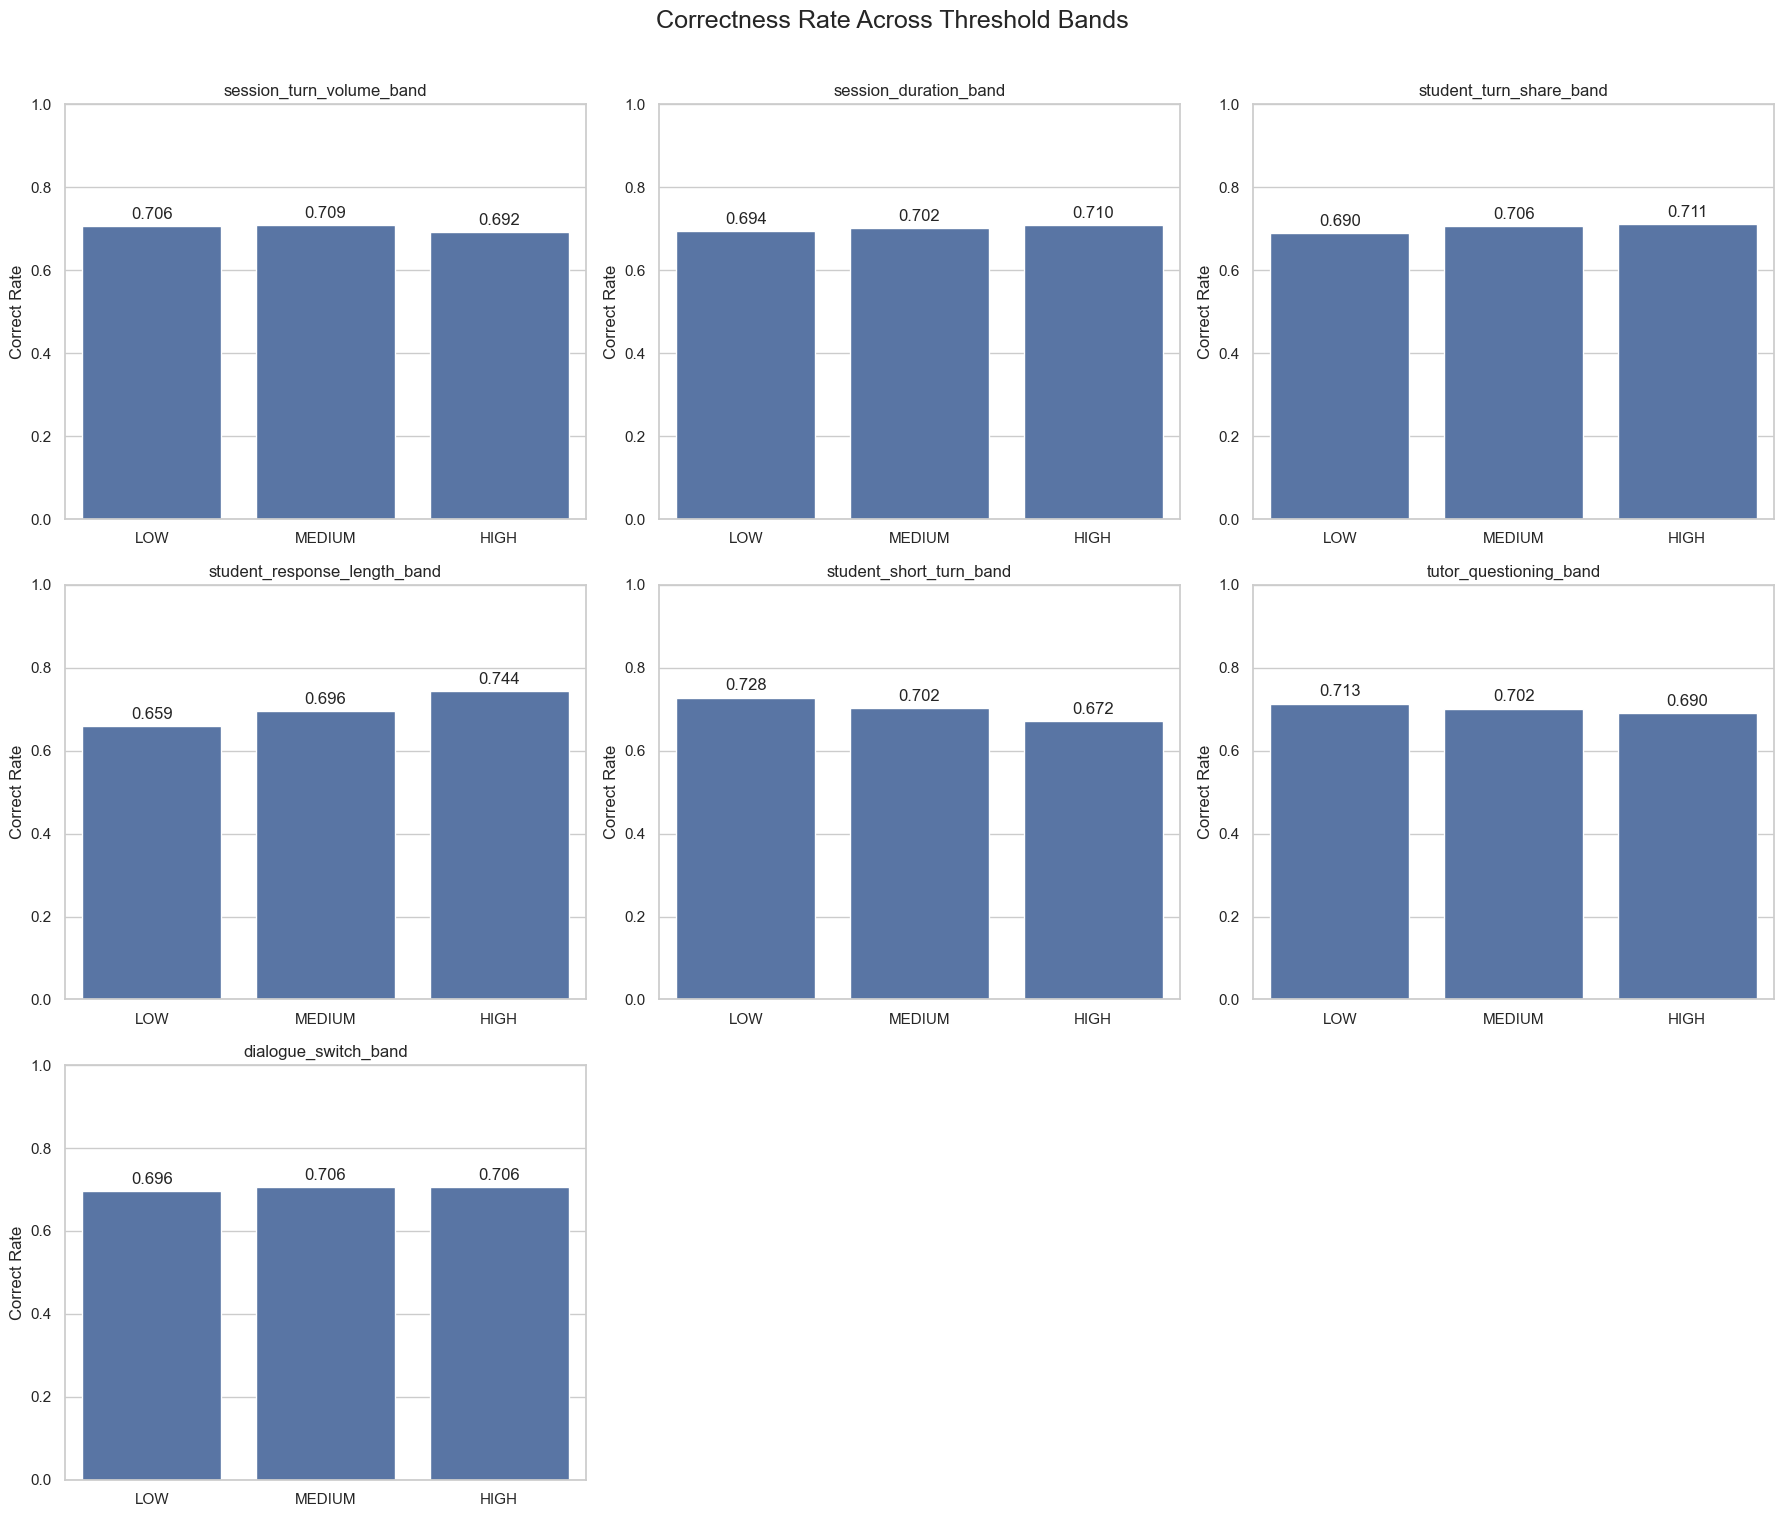

,feature_name,band,response_count,correct_rate
0,session_turn_volume_band,HIGH,11249,0.6920
1,session_turn_volume_band,LOW,11811,0.7060
2,session_turn_volume_band,MEDIUM,12012,0.7090
3,session_duration_band,HIGH,12221,0.7100
4,session_duration_band,LOW,10656,0.6940
5,session_duration_band,MEDIUM,12195,0.7020
6,student_turn_share_band,HIGH,11769,0.7110
7,student_turn_share_band,LOW,11744,0.6900
8,student_turn_share_band,MEDIUM,11559,0.7060
9,student_response_length_band,HIGH,12906,0.7440


In [14]:
band_order = ["LOW", "MEDIUM", "HIGH"]

rows = int(np.ceil(len(band_features) / 3))

fig, axes = plt.subplots(rows, 3, figsize=(18, rows * 5))
axes = np.array(axes).reshape(-1)

band_summary_rows = []

for index, feature in enumerate(band_features):
    plot_data = (
        df.groupby(feature, dropna=False)
        .agg(
            response_count=("correct", "size"),
            correct_rate=("correct", "mean"),
        )
        .reset_index()
    )

    plot_data[feature] = plot_data[feature].fillna("MISSING").astype(str)

    existing_order = [value for value in band_order if value in plot_data[feature].values]
    remaining_values = [value for value in plot_data[feature].values if value not in existing_order]
    category_order = existing_order + remaining_values

    sns.barplot(
        data=plot_data,
        x=feature,
        y="correct_rate",
        order=category_order,
        ax=axes[index],
    )

    axes[index].set_title(feature)
    axes[index].set_xlabel("")
    axes[index].set_ylabel("Correct Rate")
    axes[index].set_ylim(0, 1)

    for container in axes[index].containers:
        axes[index].bar_label(container, fmt="%.3f", padding=3)

    plot_data.insert(0, "feature_name", feature)
    plot_data = plot_data.rename(columns={feature: "band"})
    band_summary_rows.append(plot_data)

for index in range(len(band_features), len(axes)):
    axes[index].axis("off")

plt.suptitle("Correctness Rate Across Threshold Bands", fontsize=18, y=1.01)
plt.tight_layout()
plt.show()

band_target_summary = pd.concat(band_summary_rows, ignore_index=True)
display(band_target_summary.round(3))

### Interpretation of Correctness Across Threshold Bands

1. **Session turn volume has no clear linear relationship with correctness.** Medium-volume sessions perform slightly better (`0.709`), while high-volume sessions fall to `0.692`.
2. **Session duration shows a small positive trend**, increasing from `0.694` in the low band to `0.710` in the high band.
3. **Student turn share is positively associated with correctness.** The correct rate rises from `0.690` to `0.711` as student participation increases.
4. **Student response length shows the strongest positive pattern.** Correctness increases substantially from `0.659` in the low band to `0.744` in the high band.
5. **Student short-turn frequency has a clear negative relationship with correctness.** The rate decreases from `0.728` to `0.672`.
6. **Tutor questioning frequency also shows a negative trend**, declining from `0.713` in the low band to `0.690` in the high band.
7. **Dialogue switching has only a small effect.** Medium and high bands both achieve approximately `0.706`, compared with `0.696` in the low band.
8. The largest difference between the low and high bands appears in **student response length**, with an increase of about `0.085`.
9. These findings suggest that **response quality and depth may be more important than total conversation volume**.
10. The plots show group-level associations only; statistical tests are required to determine whether the differences are significant.

### Main Threshold-Band Findings

| Feature band                       | Observed pattern   | Low → High correctness | Interpretation                                                                     |
| ---------------------------------- | ------------------ | ---------------------: | ---------------------------------------------------------------------------------- |
| Student response length            | Strong positive    |        `0.659 → 0.744` | Longer and more detailed student responses are associated with better performance. |
| Student short turns                | Strong negative    |        `0.728 → 0.672` | Frequent short responses are associated with lower correctness.                    |
| Student turn share                 | Positive           |        `0.690 → 0.711` | Greater student participation relates to slightly better outcomes.                 |
| Session duration                   | Mild positive      |        `0.694 → 0.710` | Longer sessions show a small improvement in correctness.                           |
| Tutor questioning                  | Mild negative      |        `0.713 → 0.690` | Excessive tutor questioning may reflect sessions where students need more support. |
| Turn volume and dialogue switching | Weak or non-linear |      Small differences | Conversation quantity alone does not strongly explain correctness.                 |


 > we can remove `turn volume` 

## 10. Text Length Analysis

The text fields are analyzed using:

- Character count
- Word count
- Empty-text frequency
- Distribution of transcript length

Text content is not cleaned or transformed in the EDA notebook.

,column,empty_count,mean_characters,median_characters,maximum_characters,mean_words,median_words,maximum_words
0,learning_objective,0,42.4700,39.0000,83,6.5600,6.0000,15
1,transcript_text,0,"20,958.8100","21,186.0000",49333,"3,913.9700","3,957.0000",9134
2,student_text,5,"4,871.0700","4,688.0000",16207,974.9800,934.0000,3385
3,tutor_text,0,"13,063.7300","12,992.0000",33781,"2,558.1300","2,543.0000",6453


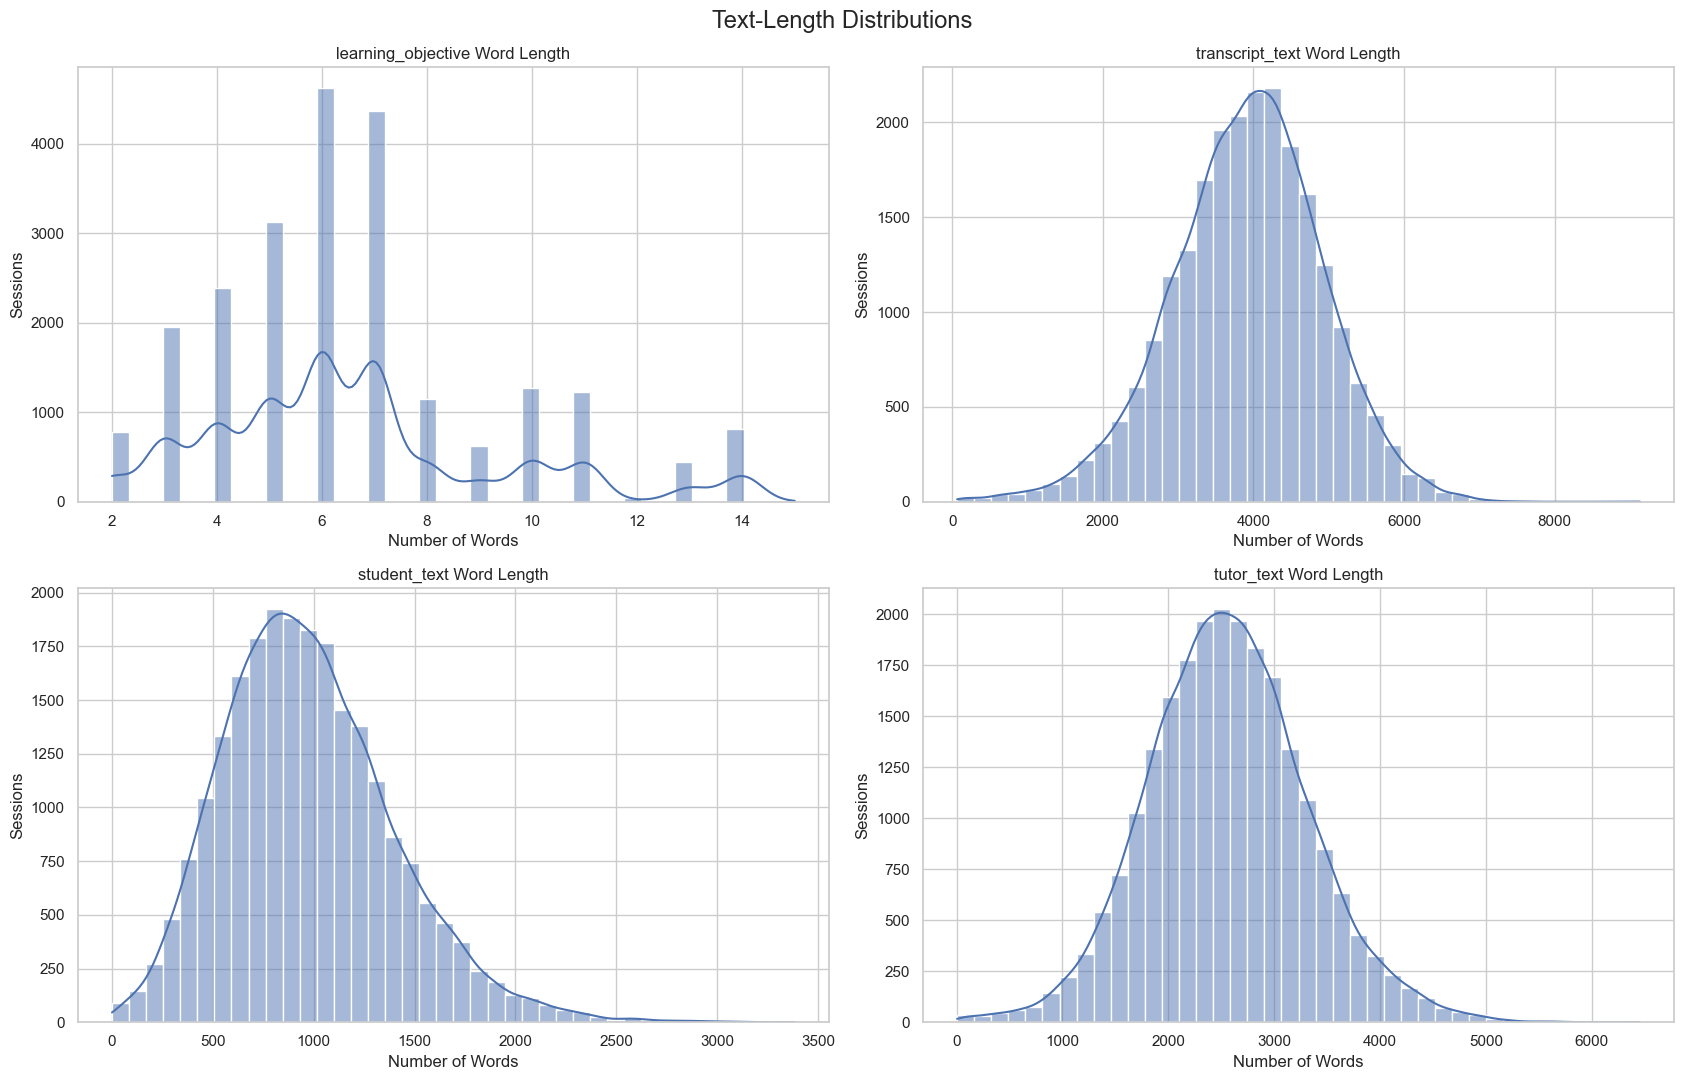

In [15]:
text_columns = ["learning_objective", "transcript_text", "student_text", "tutor_text"]
text_columns = [column for column in text_columns if column in session_df.columns]

text_summary_rows = []

for column in text_columns:
    text = session_df[column].fillna("").astype(str)
    character_length = text.str.len()
    word_length = text.str.findall(r"\b[\w']+\b").str.len()

    session_df[f"{column}_char_length"] = character_length
    session_df[f"{column}_word_length"] = word_length

    text_summary_rows.append({
        "column": column,
        "empty_count": text.str.strip().eq("").sum(),
        "mean_characters": character_length.mean(),
        "median_characters": character_length.median(),
        "maximum_characters": character_length.max(),
        "mean_words": word_length.mean(),
        "median_words": word_length.median(),
        "maximum_words": word_length.max(),
    })

text_summary = pd.DataFrame(text_summary_rows)
display(text_summary.round(2))


fig, axes = plt.subplots(2, 2, figsize=(17, 11))
axes = axes.flatten()

for index, column in enumerate(text_columns[:4]):
    sns.histplot(
        session_df[f"{column}_word_length"],
        bins=40,
        kde=True,
        ax=axes[index],
    )

    axes[index].set_title(f"{column} Word Length")
    axes[index].set_xlabel("Number of Words")
    axes[index].set_ylabel("Sessions")

plt.suptitle("Text-Length Distributions", fontsize=17)
plt.tight_layout()
plt.show()

### Insights from the Text-Length Distributions

1. **Learning objectives are generally very short**, ranging from approximately 2 to 14 words.
2. Most learning objectives contain around **5–7 words**, with the highest frequencies near 6 and 7 words.
3. The learning-objective distribution is discrete and multimodal because the values represent small integer word counts.
4. Total transcript length is concentrated around **3,500–4,500 words per session**.
5. The transcript-length distribution is approximately bell-shaped, with a slight right tail caused by a few very long sessions.
6. Student text length is mostly concentrated around **600–1,200 words**, with a peak near 800–1,000 words.
7. Student text length is positively skewed, indicating that a small number of students contribute unusually large amounts of text.
8. Tutor text length is mainly concentrated around **2,000–3,200 words**, peaking near 2,400–2,700 words.
9. Tutors generally contribute substantially more words than students, which is consistent with the previously observed low student word ratio.
10. Overall, session transcripts appear relatively consistent, but extreme student, tutor, and total transcript lengths should be checked before modelling.

### Main Distribution Findings

| Text feature                   |             Typical range | Distribution pattern    | Main interpretation                                                          |
| ------------------------------ | ------------------------: | ----------------------- | ---------------------------------------------------------------------------- |
| `learning_objective`           |                 5–7 words | Discrete and multimodal | Objectives are short and concise.                                            |
| `transcript_text`              |         3,500–4,500 words | Approximately normal    | Most sessions have similar overall transcript lengths.                       |
| `student_text`                 |           600–1,200 words | Right-skewed            | Most students contribute moderately, with some highly verbal sessions.       |
| `tutor_text`                   |         2,000–3,200 words | Nearly bell-shaped      | Tutors provide the majority of session content.                              |
| Student vs. tutor contribution | Tutor text is much longer | Unequal contribution    | Sessions are predominantly tutor-led.                                        |
| Modelling consideration        |          Long upper tails | Possible outliers       | Consider `log1p`, `Yeo-Johnson`, or `RobustScaler` for text-length features. |


## 11. Transcript Length and Student Contribution

The scatter plot compares:

- Total transcript length
- Student-only text length
- Session correctness rate

This helps identify whether longer student participation has a visible
relationship with assessment outcomes.

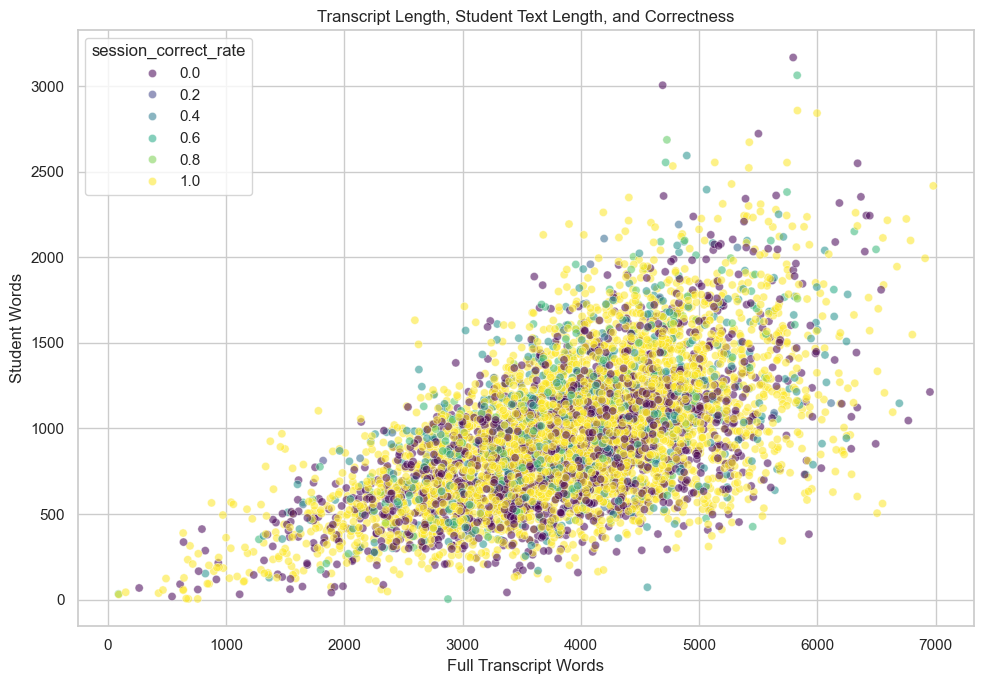

In [16]:
text_relationship = session_df[
    [
        "session_id",
        "transcript_text_word_length",
        "student_text_word_length",
    ]
].merge(session_target, on="session_id", how="left")

text_sample = text_relationship.sample(min(6000, len(text_relationship)), random_state=42)

plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=text_sample,
    x="transcript_text_word_length",
    y="student_text_word_length",
    hue="session_correct_rate",
    palette="viridis",
    alpha=0.55,
    s=35,
)

plt.title("Transcript Length, Student Text Length, and Correctness")
plt.xlabel("Full Transcript Words")
plt.ylabel("Student Words")
plt.tight_layout()
plt.show()

### Insights from Transcript Length, Student Text Length, and Correctness

1. **Student text length increases strongly with total transcript length**, indicating a clear positive relationship between the two variables.
2. Most sessions contain approximately **2,500–5,500 transcript words** and **300–1,500 student words**.
3. The upward pattern suggests that longer sessions generally provide students with more opportunities to contribute.
4. The spread of student word counts becomes wider as transcript length increases, indicating greater variation in student participation during longer sessions.
5. Sessions with the same transcript length can have very different student word counts, showing that session length alone does not determine student engagement.
6. Correctness categories are heavily mixed throughout the plot, with no clearly separated regions for low- and high-performing sessions.
7. High-correctness sessions appear across both short and long transcripts, suggesting that transcript length alone is not a strong predictor of correctness.
8. Some long sessions contain relatively little student text, which may indicate strongly tutor-led conversations.
9. A small number of sessions have unusually high transcript and student word counts and should be examined as potential outliers.
10. Overall, the plot suggests that **student participation is closely related to transcript length, but correctness depends on additional factors beyond text volume**.

### Main Findings

| Observation                         | Evidence from the plot                                               | Interpretation                                                      |
| ----------------------------------- | -------------------------------------------------------------------- | ------------------------------------------------------------------- |
| Strong positive length relationship | Points form a clear upward pattern                                   | Longer transcripts generally contain more student words.            |
| Increasing variability              | The point cloud becomes wider toward the right                       | Student participation varies more in longer sessions.               |
| Weak correctness separation         | Correctness colours overlap across the plot                          | Text length alone cannot clearly distinguish performance levels.    |
| Tutor-dominated sessions            | Some sessions have high transcript length but low student word count | Longer sessions are not always more student-centred.                |
| Potential extreme sessions          | A few points exceed 6,000 transcript words or 2,500 student words    | These observations should be reviewed before modelling.             |
| Modelling implication               | Length and participation are related                                 | Use ratios such as `student_word_ratio` alongside raw text lengths. |


## 12. Responses per Session

A single tutoring session may be connected to multiple assessment
responses.

Repeated `session_id` values are valid and should not be removed from the
model-training dataset.

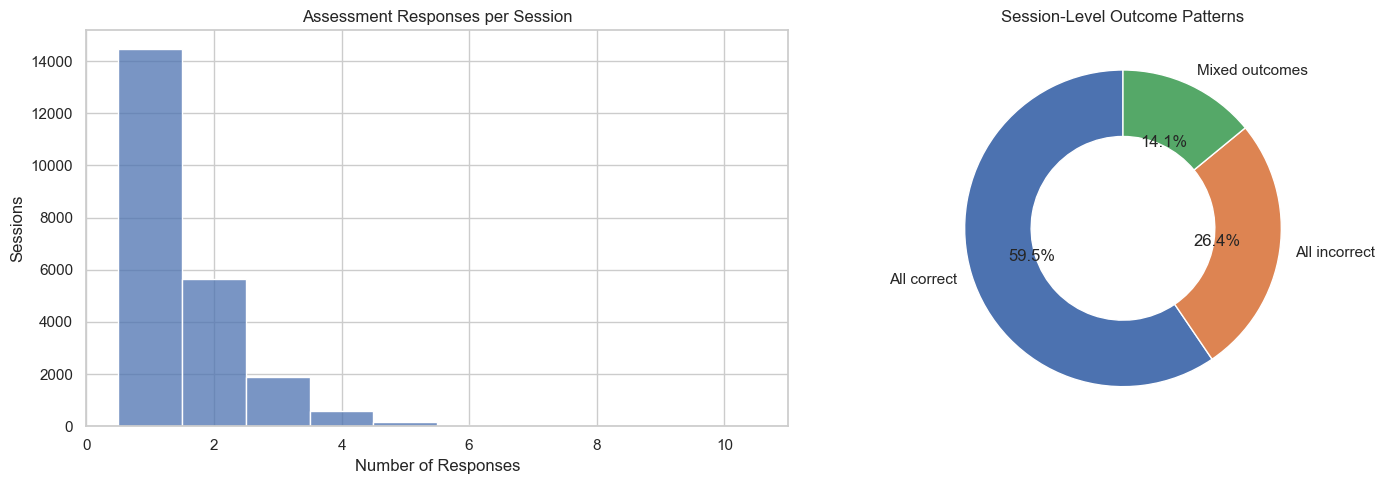

,value
count,"22,821.0000"
mean,1.5368
std,0.8572
min,1.0000
25%,1.0000
50%,1.0000
75%,2.0000
max,10.0000


,session_count
pattern,
All correct,13582
All incorrect,6032
Mixed outcomes,3207


In [17]:
responses_per_session = df.groupby("session_id").size()

session_label_pattern = (
    df.groupby("session_id")["correct"]
    .agg(["min", "max", "count"])
    .reset_index()
)

session_label_pattern["pattern"] = np.select(
    [
        (session_label_pattern["min"] == 0) & (session_label_pattern["max"] == 1),
        session_label_pattern["min"] == 1,
        session_label_pattern["max"] == 0,
    ],
    [
        "Mixed outcomes",
        "All correct",
        "All incorrect",
    ],
    default="Unknown",
)

pattern_counts = session_label_pattern["pattern"].value_counts()


fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.histplot(responses_per_session, discrete=True, ax=axes[0])
axes[0].set_title("Assessment Responses per Session")
axes[0].set_xlabel("Number of Responses")
axes[0].set_ylabel("Sessions")

axes[1].pie(
    pattern_counts.values,
    labels=pattern_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    wedgeprops={"width": 0.42},
)

axes[1].set_title("Session-Level Outcome Patterns")

plt.tight_layout()
plt.show()


display(responses_per_session.describe().rename("value").to_frame())
display(pattern_counts.rename("session_count").to_frame())

### Insights from Assessment Responses and Session Outcomes

1. Most sessions contain only **one assessment response**, accounting for approximately 14,000 sessions.
2. Sessions with **two responses** are much less common, while sessions with three or more responses are relatively rare.
3. The number of sessions decreases sharply as the response count increases, producing a strongly right-skewed distribution.
4. Approximately **59.5% of sessions have all responses correct**, making this the largest outcome group.
5. Around **26.4% of sessions have all responses incorrect**, indicating a substantial group with no successful assessment response.
6. Only **14.1% of sessions contain mixed outcomes**, where the student answers some questions correctly and others incorrectly.
7. The low percentage of mixed outcomes is largely explained by the high number of sessions containing only one response.
8. For one-response sessions, the correct rate can only be `0` or `1`, which explains the strong concentration at these values in earlier plots.
9. Session-level correctness may be unstable when it is calculated from only one or two assessment responses.
10. Performance comparisons should therefore consider `response_count` alongside `session_correct_rate`.

### Main Findings and Modelling Implications

| Observation                |                                Result | Interpretation                                                                  |
| -------------------------- | ------------------------------------: | ------------------------------------------------------------------------------- |
| Most common response count |                            1 response | Most session outcomes are based on a single assessment item.                    |
| All-correct sessions       |                                 59.5% | The majority of sessions recorded only correct outcomes.                        |
| All-incorrect sessions     |                                 26.4% | More than one-quarter of sessions recorded no correct outcome.                  |
| Mixed-outcome sessions     |                                 14.1% | Mixed results are uncommon because few sessions contain multiple responses.     |
| Main analytical limitation |               Unequal response counts | Correctness estimates from low-response sessions are less reliable.             |
| Recommended approach       | Control or weight by `response_count` | Use minimum-response filtering, weighted analysis, or response-level modelling. |


## 13. EDA Summary and Saved Outputs

The main EDA tables are saved for later comparison.

No rows or features are changed in this notebook. Transformations and
train-validation splitting will be performed in the feature-engineering
notebook.

In [18]:
eda_output_dir = dataset_root / "outputs" / "04_eda"
eda_output_dir.mkdir(parents=True, exist_ok=True)

overview.to_csv(eda_output_dir / "dataset_overview.csv", index=False)
missing_summary.to_csv(eda_output_dir / "missing_summary.csv")
target_summary.to_csv(eda_output_dir / "target_summary.csv", index=False)
numerical_summary.to_csv(eda_output_dir / "numerical_summary.csv")
outlier_summary.to_csv(eda_output_dir / "outlier_summary.csv", index=False)
feature_target_correlation.to_csv(eda_output_dir / "feature_target_correlation.csv")
correlation_matrix.to_csv(eda_output_dir / "correlation_matrix.csv")
high_correlation_pairs.to_csv(eda_output_dir / "high_correlation_pairs.csv", index=False)
band_target_summary.to_csv(eda_output_dir / "band_target_summary.csv", index=False)
text_summary.to_csv(eda_output_dir / "text_summary.csv", index=False)

print("EDA completed successfully.")
print("Output folder          :", eda_output_dir)
print("Response-level rows    :", f"{len(df):,}")
print("Unique sessions        :", f"{len(session_df):,}")
print("Positive response rate :", f"{df['correct'].mean() * 100:.2f}%")
print("Numerical features     :", len(numerical_features))
print("Band features          :", len(band_features))
print("High correlation pairs :", len(high_correlation_pairs))

EDA completed successfully.
Output folder          : C:\Users\USER\Kawsar_Ahmmed\ALL_Projects_Lab\Trace-The-Race-Competition\Trace-The-Race-Dataset\outputs\04_eda
Response-level rows    : 35,072
Unique sessions        : 22,821
Positive response rate : 70.25%
Numerical features     : 20
Band features          : 7
High correlation pairs : 6
